<a href="https://colab.research.google.com/github/Longhanhmid24/DoAn_Email/blob/main/perplexity_Qwen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:


import torch, math, pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM

# ===== LOAD MODEL =====
model_path = "/content/drive/MyDrive/Deep_Learning_Email/qwen_finetuned_final"

model = AutoModelForCausalLM.from_pretrained(model_path).to("cuda")
tokenizer = AutoTokenizer.from_pretrained(model_path)

model.eval()

# ===== LOAD DATA =====
file_path = "/content/drive/MyDrive/Deep_Learning_Email/dataset_split/test.csv"

df = pd.read_csv(file_path)

print("Columns:", df.columns)

texts = df["Output_Text"].dropna().astype(str).tolist()

print("Samples:", len(texts))


losses = []

for text in texts[:200]:  # test 200 sample trước
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to("cuda")

    with torch.no_grad():
        outputs = model(**inputs, labels=inputs["input_ids"])
        loss = outputs.loss

    losses.append(loss.item())

ppl = math.exp(sum(losses)/len(losses))

print("Perplexity:", ppl)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

Columns: Index(['Input_Text', 'Output_Text'], dtype='object')
Samples: 640
Perplexity: 74.9616519016005


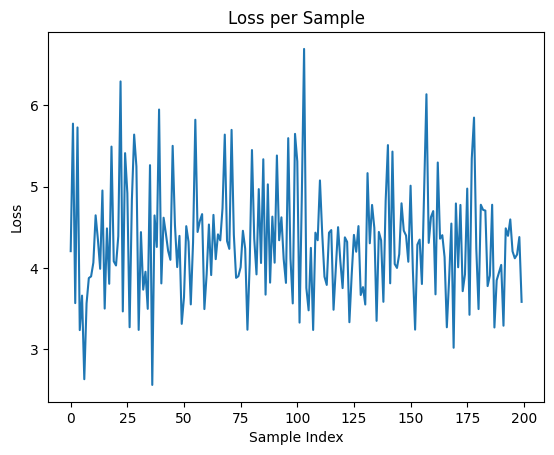

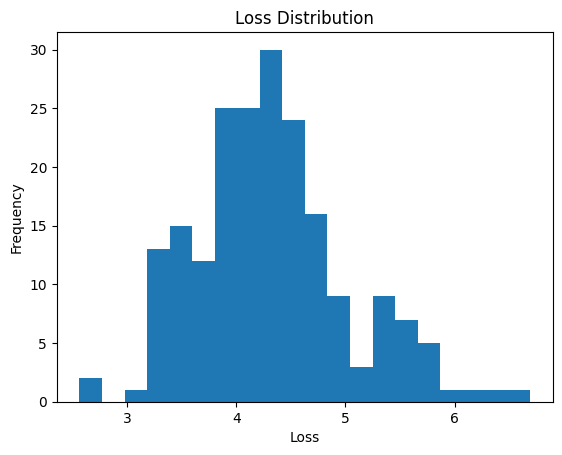

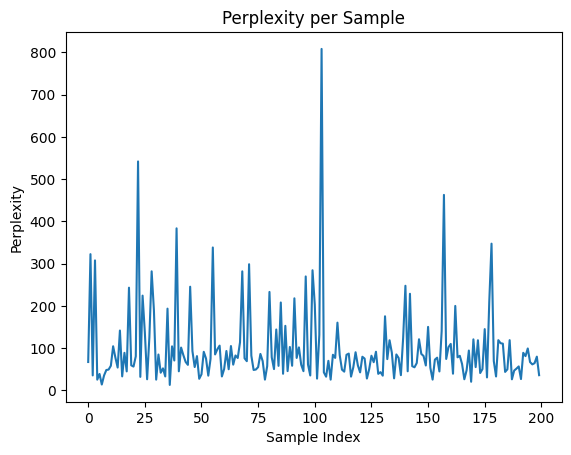

In [3]:
import matplotlib.pyplot as plt

# ===== 1. Loss theo từng sample =====
plt.figure()
plt.plot(losses)
plt.title("Loss per Sample")
plt.xlabel("Sample Index")
plt.ylabel("Loss")
plt.show()

# ===== 2. Phân phối loss =====
plt.figure()
plt.hist(losses, bins=20)
plt.title("Loss Distribution")
plt.xlabel("Loss")
plt.ylabel("Frequency")
plt.show()

# ===== 3. Perplexity per sample (optional xịn hơn) =====
import math

ppl_per_sample = [math.exp(l) for l in losses]

plt.figure()
plt.plot(ppl_per_sample)
plt.title("Perplexity per Sample")
plt.xlabel("Sample Index")
plt.ylabel("Perplexity")
plt.show()